In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving factory_production.csv to factory_production.csv


In [5]:
df = pd.read_csv('factory_production.csv')
df.head(10)

,Tanggal,Shift,Mesin,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
0,2025-11-01,Pagi,A,376,6,9.9,80.3,55.3
1,2025-11-01,Pagi,B,351,4,54.4,82.1,35.4
2,2025-11-01,Pagi,C,395,8,2.0,72.8,55.2
3,2025-11-01,Pagi,D,466,6,20.3,70.4,54.6
4,2025-11-01,Siang,A,339,3,3.2,70.0,51.9
5,2025-11-01,Siang,B,224,2,11.6,79.4,49.9
6,2025-11-01,Siang,C,294,8,5.7,85.7,68.4
7,2025-11-01,Siang,D,353,10,4.6,80.6,46.7
8,2025-11-01,Malam,A,254,10,10.0,91.1,59.6
9,2025-11-01,Malam,B,231,6,1.8,79.4,63.9


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1080 non-null   object 
 1   Shift             1080 non-null   object 
 2   Mesin             1080 non-null   object 
 3   Jumlah_Produksi   1080 non-null   int64  
 4   Jumlah_Cacat      1080 non-null   int64  
 5   Downtime (menit)  1059 non-null   float64
 6   Suhu_Mesin        1048 non-null   float64
 7   Kelembaban        1037 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 67.6+ KB


,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
count,1080.000000,1080.000000,1059.000000,1048.000000,1037.000000
mean,349.600000,7.934259,15.110009,76.951718,49.857281
std,59.510571,4.416073,15.214485,8.218287,10.178976
min,142.000000,0.000000,0.000000,55.000000,25.000000
25%,311.000000,5.000000,4.300000,70.900000,42.900000
50%,349.000000,7.000000,10.800000,77.100000,49.900000
75%,390.250000,10.000000,20.200000,82.500000,56.800000
max,528.000000,42.000000,110.300000,104.900000,79.200000


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
Downtime (menit),21,1.944444
Suhu_Mesin,32,2.962963
Kelembaban,43,3.981481


In [8]:
#menangani missing pada kolom 'Downtime (menit)'
median_downtime = df['Downtime (menit)'].median()
df['Downtime (menit)'] = df['Downtime (menit)'].fillna(median_downtime)

In [9]:
#menangani missing pada kolom 'Suhu_Mesin'
median_suhu = df['Suhu_Mesin'].median()
df['Suhu_Mesin'] = df['Suhu_Mesin'].fillna(median_suhu)

In [10]:
#menangani missing pada kolom 'Kelembaban'
median_kelembaban = df['Kelembaban'].median()
df['Kelembaban'] = df['Kelembaban'].fillna(median_suhu)

In [11]:
df.isnull().sum()

,0
Tanggal,0
Shift,0
Mesin,0
Jumlah_Produksi,0
Jumlah_Cacat,0
Downtime (menit),0
Suhu_Mesin,0
Kelembaban,0


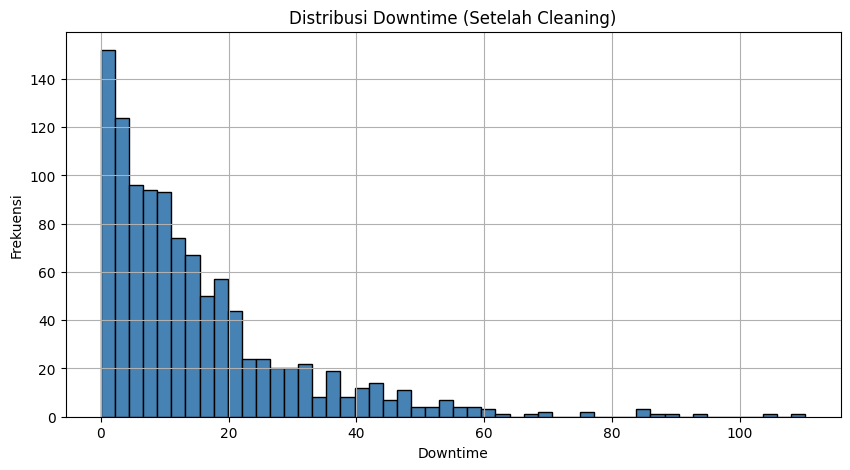

In [12]:
plt.figure(figsize=(10, 5))
df['Downtime (menit)'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi Downtime (Setelah Cleaning)')
plt.xlabel('Downtime')
plt.ylabel('Frekuensi')
plt.show()

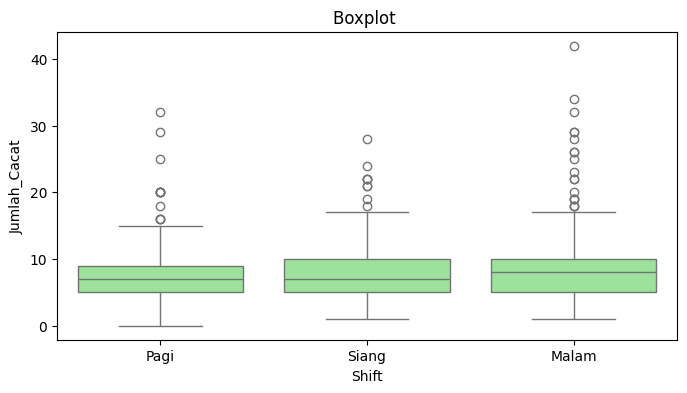

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df,x='Shift',y='Jumlah_Cacat', color='lightgreen')
plt.title('Boxplot ')
plt.show()

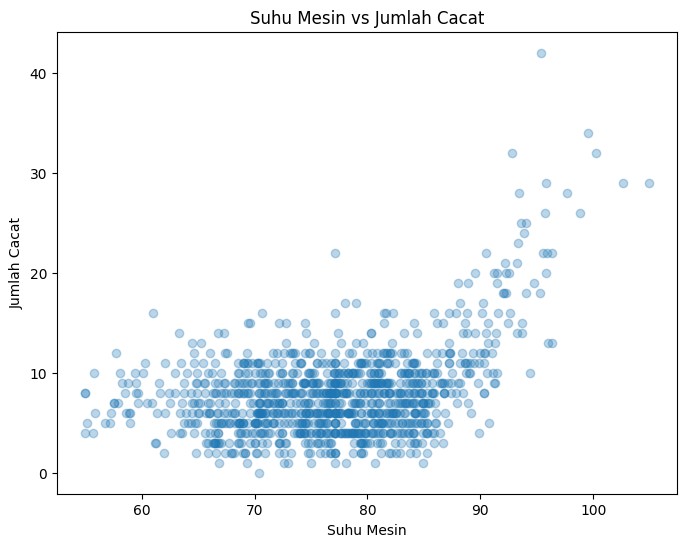

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Suhu_Mesin'], df['Jumlah_Cacat'], alpha=0.3)
plt.xlabel('Suhu Mesin')
plt.ylabel('Jumlah Cacat')
plt.title('Suhu Mesin vs Jumlah Cacat')
plt.show()

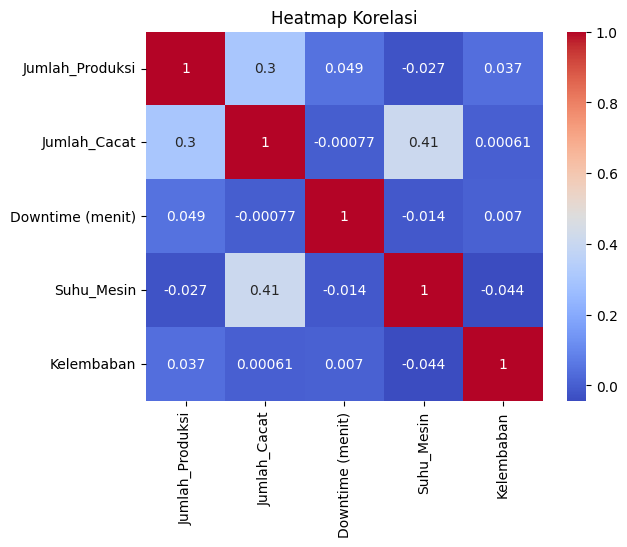

In [15]:
num_cols = ['Jumlah_Produksi', 'Jumlah_Cacat', 'Downtime (menit)', 'Suhu_Mesin', 'Kelembaban']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()